In [1]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Импорты
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
import os


In [3]:
#Загрузка данных
os.chdir('..')  # перейти в корень проекта
#Загрузка данных
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
sub   = pd.read_csv("data/sample_submission.csv")

In [4]:
#Первичный анализ
train.head(5)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.describe()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [7]:
train.columns

Index(['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=214)

In [8]:
print("Пропусков: ", train.isna().sum().sum())

Пропусков:  24


Из первичного анализа тренировочного датасета видно, что данные представлены исключительно числовыми значениями.
Причем некоторые признаки представлены чисто 0 и 1 (уже закодированные категориальные признаки).

Пропусков в данных 24 / (751*214), что меньше 1% - такими пропусками можно пренебречь.

In [9]:
X_train = train.drop(['index', 'IC50, mM', 'CC50, mM', 'SI'], axis=1)

y_ic50 = train['IC50, mM'].values.astype(np.float64)
y_cc50 = train['CC50, mM'].values.astype(np.float64)
y_si   = train['SI'].values.astype(np.float64)

In [10]:
var_series = X_train.var().sort_values()
print("Признаки с низкой дисперсией (< 0.001):")
print(var_series[var_series < 0.001])

Признаки с низкой дисперсией (< 0.001):
NumRadicalElectrons    0.0
SMR_VSA8               0.0
SlogP_VSA9             0.0
fr_thiocyan            0.0
fr_phos_acid           0.0
fr_isothiocyan         0.0
fr_nitroso             0.0
fr_lactam              0.0
fr_benzodiazepine      0.0
fr_diazo               0.0
fr_dihydropyridine     0.0
fr_isocyan             0.0
fr_SH                  0.0
fr_barbitur            0.0
fr_azide               0.0
fr_N_O                 0.0
fr_prisulfonamd        0.0
fr_phos_ester          0.0
dtype: float64


Эти признаки имеют очень низкую вариативность и не дадут значимости для модели - можно удалить.

Бинарные fr_* признаки с редкими фрагментами тоже попадают сюда, но их вклад минимален - в будущем можно рассмотреть их и добавить для улучшения точности модели.

In [11]:
corr_list = []
for c in X_train.columns:
    r1 = abs(stats.spearmanr(X_train[c], y_ic50)[0])
    r2 = abs(stats.spearmanr(X_train[c], y_cc50)[0])
    r3 = abs(stats.spearmanr(X_train[c], y_si)[0])
    corr_list.append((c, max(r1, r2, r3)))

corr_df = pd.DataFrame(corr_list, columns=["признак", "макс_корреляция"])
corr_df = corr_df.sort_values("макс_корреляция", ascending=False)

print("Топ-12 признаков:")
print(corr_df.head(12))

Топ-12 признаков:
                      признак  макс_корреляция
45                     Kappa3         0.292102
44                     Kappa2         0.291328
43                     Kappa1         0.284115
120  NumSaturatedHeterocycles         0.281584
9         NumValenceElectrons         0.269125
29                       Chi0         0.268556
16           FpDensityMorgan2         0.267919
124                     MolMR         0.266274
30                      Chi0n         0.265090
31                      Chi0v         0.262846
46                  LabuteASA         0.262113
15           FpDensityMorgan1         0.260579


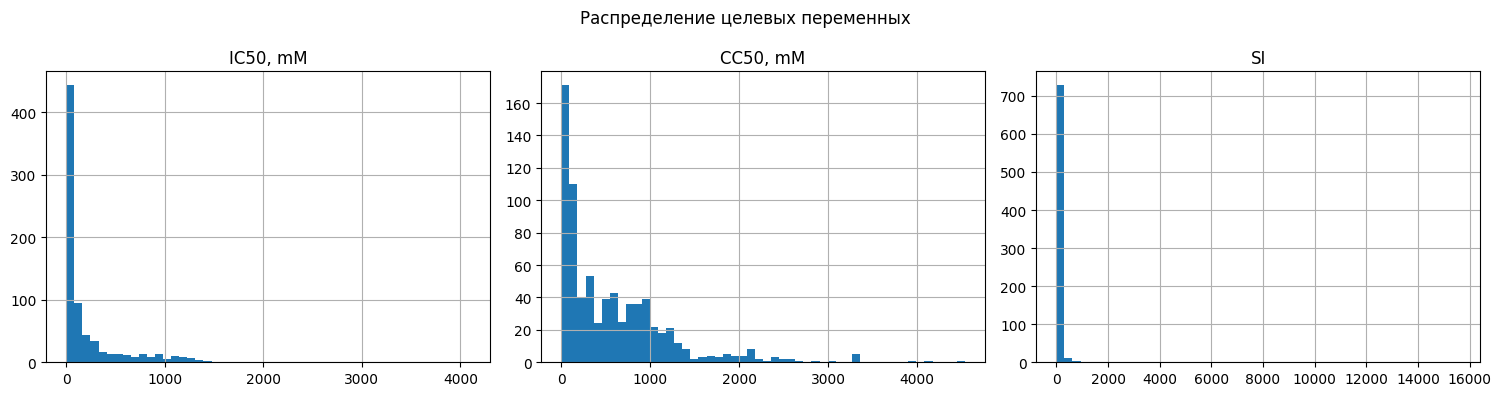

In [12]:
# Распределение целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['IC50, mM'].hist(ax=axes[0], bins=50)
axes[0].set_title('IC50, mM')

train['CC50, mM'].hist(ax=axes[1], bins=50)
axes[1].set_title('CC50, mM')

train['SI'].hist(ax=axes[2], bins=50)
axes[2].set_title('SI')

plt.suptitle('Распределение целевых переменных')
plt.tight_layout()
plt.show()

Видно что все три целевых переменных имеют правостороннее распределение с выбросами. Предлагаю обработать их по 99% перцентелю с преобразованием в корень - это даст меньший разброс данных и большую точность модели.

In [13]:
#Обработка выбросов в целевых переменных
y_ic50_raw = train['IC50, mM'].values.astype(np.float64)
y_cc50_raw = train['CC50, mM'].values.astype(np.float64)
y_si_raw   = train['SI'].values.astype(np.float64)

ic50_p99 = np.percentile(y_ic50_raw, 99)
cc50_p99 = np.percentile(y_cc50_raw, 99)
si_p95 = np.percentile(y_si_raw, 95)

y_ic50 = np.sqrt(np.clip(y_ic50_raw, 0, ic50_p99))
y_cc50 = np.sqrt(np.clip(y_cc50_raw, 0, cc50_p99))
y_si   = np.log1p(np.clip(y_si_raw, 0, si_p95))

print(f"99% перцентель — IC50: {ic50_p99:.1f}, CC50: {cc50_p99:.1f}")
print(f"95% перцентель — SI:   {si_p95:.1f}")

99% перцентель — IC50: 1334.3, CC50: 3162.0
95% перцентель — SI:   138.4


In [14]:
# Удаляем признаки с низкой дисперсией
var_series = X_train.var().sort_values()
X_train = X_train.drop(var_series[var_series < 0.001].index.tolist(), axis=1)

In [15]:
# Feature engineering — логарифмы и отношения признаков
feat_base = X_train.columns.tolist()

for c in feat_base:
    if X_train[c].min() > 0:
        X_train[f"log_{c}"] = np.log1p(X_train[c])
        test[f"log_{c}"]    = np.log1p(test[c])

top12 = feat_base[:12]
for i in range(len(top12)):
    for j in range(i+1, len(top12)):
        X_train[f"r_{i}_{j}"] = X_train[top12[i]] / (X_train[top12[j]] + 1e-8)
        test[f"r_{i}_{j}"]    = test[top12[i]]    / (test[top12[j]]    + 1e-8)

print(f"Итоговых признаков: {X_train.shape[1]}")

X      = np.nan_to_num(X_train.values.astype(np.float64), nan=0, posinf=0, neginf=0)
X_test = np.nan_to_num(test[X_train.columns].values.astype(np.float64), nan=0, posinf=0, neginf=0)

Итоговых признаков: 299


In [16]:
# CatBoost модель
cat_p = dict(
    iterations=5000,
    learning_rate=0.01,
    depth=4,
    subsample=0.8,
    l2_leaf_reg=5,
    min_data_in_leaf=10,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=0,
    early_stopping_rounds=500,
)

In [17]:
#Отдельная функция для краткости кода ниже
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [18]:
#Обучение и кросс-валидация
N = 5
kf = KFold(n_splits=N, shuffle=True, random_state=42)

oof_ic50  = np.zeros(len(X))
oof_cc50  = np.zeros(len(X))
oof_si    = np.zeros(len(X))
pred_ic50 = np.zeros(len(X_test))
pred_cc50 = np.zeros(len(X_test))
pred_si   = np.zeros(len(X_test))

for fold, (tr, val) in enumerate(kf.split(X), 1):
    print(f"Fold {fold}/{N}")
    Xtr, Xval = X[tr], X[val]

    # IC50
    m_ic50 = CatBoostRegressor(**cat_p)
    m_ic50.fit(Xtr, y_ic50[tr], eval_set=(Xval, y_ic50[val]), use_best_model=True)
    oof_ic50[val]  = np.clip(m_ic50.predict(Xval),   0, None) ** 2
    pred_ic50     += np.clip(m_ic50.predict(X_test), 0, None) ** 2 / N

    # CC50
    m_cc50 = CatBoostRegressor(**cat_p)
    m_cc50.fit(Xtr, y_cc50[tr], eval_set=(Xval, y_cc50[val]), use_best_model=True)
    oof_cc50[val]  = np.clip(m_cc50.predict(Xval),   0, None) ** 2
    pred_cc50     += np.clip(m_cc50.predict(X_test), 0, None) ** 2 / N

    # SI тут теперь log1p трансформация, обратно через expm1
    m_si = CatBoostRegressor(**cat_p)
    m_si.fit(Xtr, y_si[tr], eval_set=(Xval, y_si[val]), use_best_model=True)
    oof_si[val] = np.expm1(np.clip(m_si.predict(Xval),   0, None))
    pred_si    += np.expm1(np.clip(m_si.predict(X_test), 0, None)) / N

    r_ic = rmse(y_ic50_raw[val], oof_ic50[val])
    r_cc = rmse(y_cc50_raw[val], oof_cc50[val])
    r_si = rmse(y_si_raw[val],   oof_si[val])
    print(f"  IC50={r_ic:.1f}  CC50={r_cc:.1f}  SI={r_si:.1f}  mean={((r_ic+r_cc+r_si)/3):.1f}")

Fold 1/5
  IC50=419.0  CC50=456.3  SI=170.9  mean=348.7
Fold 2/5
  IC50=228.2  CC50=356.8  SI=403.4  mean=329.5
Fold 3/5
  IC50=349.6  CC50=435.5  SI=976.3  mean=587.2
Fold 4/5
  IC50=299.2  CC50=537.3  SI=90.5  mean=309.0
Fold 5/5
  IC50=336.1  CC50=488.2  SI=1401.0  mean=741.8


In [19]:
print("Итоговый RMSE")
r_ic = rmse(y_ic50_raw, oof_ic50)
r_cc = rmse(y_cc50_raw, oof_cc50)
r_si = rmse(y_si_raw,   oof_si)
print(f"  IC50={r_ic:.1f}  CC50={r_cc:.1f}  SI={r_si:.1f}  mean={((r_ic+r_cc+r_si)/3):.1f}")

Итоговый RMSE
  IC50=332.5  CC50=458.8  SI=788.9  mean=526.7


In [ ]:
# Предсказание
t_ic50 = np.clip(pred_ic50, 0, ic50_p99)
t_cc50 = np.clip(pred_cc50, 0, cc50_p99)
t_si   = np.clip(pred_si,   0, si_p95)

submission = pd.DataFrame({
    "index": test["index"],
    "IC50": t_ic50,
    "CC50": t_cc50,
    "SI": t_si
})

submission.to_csv("submissionv12.csv", index=False)